# Introducción a Transformers para Clasificación de Texto
## Fine-Tuning con Transformers Modernos
Objetivos del Notebook

En este laboratorio el estudiante aprenderá a:

- Comprender el funcionamiento básico de Transformers.
- Implementar modelos preentrenados modernos.
- Utilizar Hugging Face Transformers.
- Realizar fine-tuning para clasificación de texto.
- Comprender embeddings y self-attention.
- Comparar Deep Learning clásico vs Transformers.
- Analizar ventajas y limitaciones de LLMs modernos.

# Sección 1 — Introducción Conceptual
## ¿Qué es un Transformer?

Los Transformers revolucionaron NLP mediante:

- self-attention,
- paralelización,
- embeddings contextuales.

## Problema de RNNs y LSTMs

Las arquitecturas anteriores tenían dificultades con:

- dependencias largas,
- paralelización,
- escalabilidad.

## Self-Attention

La atención se calcula como:

$Attention(Q,K,V)=softmax\left ( \frac{QK^T}{\sqrt{d_k}} V \right )$

## Embeddings

Las palabras se representan como vectores:

$w_i \in \mathbb{R}^d$

## Arquitecturas modernas
- BERT
- GPT
- RoBERTa
- T5
- Llama
- Mistral

# Sección 2 — Configuración del Entorno

In [2]:
!pip install transformers datasets accelerate -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

torch.manual_seed(42)

/home/diego/Nobu/Trabajos/DiploDatos/diplodatos_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Verificar GPU

In [4]:
print(torch.cuda.is_available())

False


# Sección 3 — Dataset IMDB
## Problema

Clasificación de sentimientos:

- positivo,
- negativo.

In [6]:
dataset = load_dataset("stanfordnlp/imdb")

Generating unsupervised split: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:00<00:00, 70694.68 examples/s]


## Información

In [7]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


## Ejemplo

In [8]:
print(dataset["train"][0]["text"])

print("\nLabel:")

print(dataset["train"][0]["label"])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

## Labels

In [9]:
label_names = {
    0: "Negative",
    1: "Positive"
}

# Sección 4 — Exploración del Dataset
## Longitud de textos

In [10]:
lengths = [
    len(x["text"].split())
    for x in dataset["train"].select(range(1000))
]

## Visualización

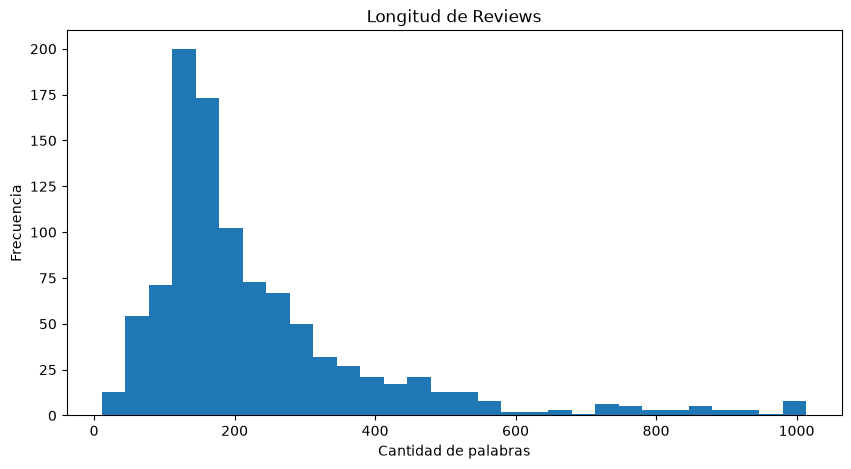

In [11]:
plt.figure(figsize=(10,5))

plt.hist(lengths, bins=30)

plt.xlabel("Cantidad de palabras")

plt.ylabel("Frecuencia")

plt.title("Longitud de Reviews")

plt.show()

## Discusión
Preguntas
- ¿Los textos son largos?
- ¿Qué desafíos presenta NLP?

# Sección 5 — Introducción a Tokenización
## ¿Qué es tokenizar?

Transformar texto en tokens numéricos.

## Modelo preentrenado

Usaremos:

- DistilBERT,
- versión liviana de BERT.

In [12]:
model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    model_checkpoint
)

## Ejemplo de tokenización

In [13]:
example = "Transformers are powerful models."

tokens = tokenizer(example)

print(tokens)

{'input_ids': [101, 19081, 2024, 3928, 4275, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


## Decodificación

In [14]:
print(
    tokenizer.convert_ids_to_tokens(
        tokens["input_ids"]
    )
)

['[CLS]', 'transformers', 'are', 'powerful', 'models', '.', '[SEP]']


# Sección 6 — Tokenización del Dataset
## Función de tokenización

In [15]:


def tokenize_function(example):

    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

##Aplicar tokenización

In [16]:
tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:33<00:00, 1473.66 examples/s]


## Reducir tamaño para Colab o nuestra compu 

In [17]:
small_train_dataset = tokenized_datasets["train"].shuffle(
    seed=42
).select(range(3000))

small_test_dataset = tokenized_datasets["test"].shuffle(
    seed=42
).select(range(1000))

# Sección 7 — Modelo Transformer
## Cargar modelo preentrenado

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2
)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2733.30it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Arquitectura

In [19]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

## Interpretación
Preguntas
- ¿Qué partes están preentrenadas?
- ¿Qué se ajusta durante fine-tuning?

# Sección 8 — Fine-Tuning
## Métricas

In [20]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    acc = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

## TrainingArguments

In [21]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=50
)

## Trainer

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_test_dataset,
    compute_metrics=compute_metrics
)

## Entrenamiento

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss


# Sección 9 — Evaluación
## Evaluación final

In [ ]:
results = trainer.evaluate()

print(results)

## Predicciones

In [ ]:
predictions = trainer.predict(
    small_test_dataset
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

## Matriz de confusión

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.title("Transformer Confusion Matrix")

plt.show()

# Sección 10 — Predicciones Individuales
## Ejemplo manual

In [ ]:
text = """
This movie was amazing. The acting and story were excellent.
"""


## okenizar

In [ ]:


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)



model.to(device)



inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)


## Inferencia

In [ ]:


inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}


with torch.no_grad():

    outputs = model(**inputs)

logits = outputs.logits

prediction = torch.argmax(
    logits,
    dim=1
).item()

print("Predicción:")

print(label_names[prediction])

# Sección 11 — Visualización Conceptual de Atención
# ¿Qué aprende atención?

La atención aprende:

- relaciones semánticas,
- contexto,
- dependencia entre palabras.

## Conceptualmente

Ejemplo:

*"The movie was not good"*

La palabra:

*not*

modifica:

*good*

## Atención contextual

Los embeddings dependen:

- del contexto,
- no solo de la palabra aislada.

# Sección 12 — Comparación Conceptual

|Modelo|	Ventaja	|Limitación|
|:---|:---|:---|
|RNN|	Secuencial|	Lenta|
|LSTM|	Mejor memoria|	Escalabilidad|
|Transformer|	Paralelizable|	Costoso|
|DistilBERT|	Liviano|	Menor capacidad|

## Discusión
Preguntas
- ¿Por qué Transformers dominaron NLP?
- ¿Qué costo computacional poseen?
- ¿Qué limitaciones observas?

# Sección 13 — Limitaciones y Ética
Riesgos
- Sesgos lingüísticos.
- Hallucinations.
- Toxicidad.
- Dependencia de datos masivos.
- Alto consumo energético.
